In [2]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

# Reliance Communications Ltd. Analysis

In [4]:
def get_data(start_date, end_date):
    ticker = "RCOM.NS"   
    
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d"
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    return data

In [6]:
data = get_data("2017-01-01", "2025-03-05")

[*********************100%***********************]  1 of 1 completed


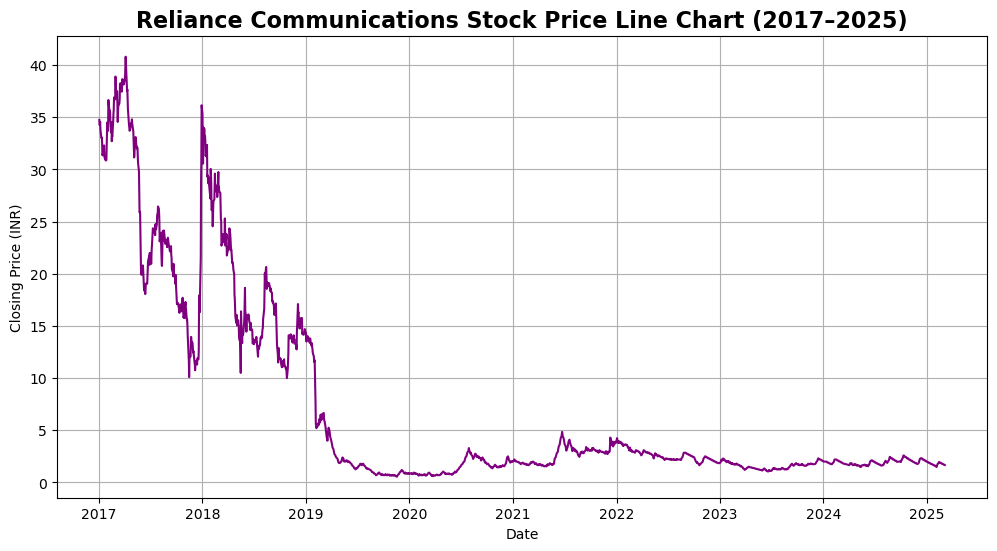

In [8]:
# Line chart 
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], color='purple')
plt.title("Reliance Communications Stock Price Line Chart (2017–2025)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid()
plt.show()

In [10]:
# The chart shows a strong downward trend over time, indicating long-term decline in stock value.
# High fluctuations are visible in the early years, reflecting significant short-term volatility.
# After a sharp fall in 2019, the stock remains low with little movement.
# Post-2020, the stock remains mostly flat with minor fluctuations, indicating limited recovery.

### Trend Analysis Using Moving Averages

In [12]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data

Price,Close,High,Low,Open,Volume,MA20,MA50
Date,,,,,,,
2017-01-02,34.750000,35.049999,33.849998,34.299999,7939382,NaN,NaN
2017-01-03,34.250000,34.900002,34.049999,34.549999,6302346,NaN,NaN
2017-01-04,34.299999,34.549999,33.799999,34.200001,6375065,NaN,NaN
2017-01-05,34.549999,34.799999,34.400002,34.500000,6878528,NaN,NaN
2017-01-06,33.799999,34.400002,33.599998,34.099998,11992721,NaN,NaN
...,...,...,...,...,...,...,...
2025-02-25,1.750000,1.750000,1.750000,1.750000,0,1.7635,1.8336
2025-02-27,1.750000,1.750000,1.750000,1.750000,0,1.7710,1.8246
2025-02-28,1.750000,1.750000,1.750000,1.750000,0,1.7785,1.8156


In [14]:
data['Trend'] = 'Downtrend'
data.loc[data['MA20'] > data['MA50'], 'Trend'] = 'Uptrend'
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend
Date,,,,,,,,
2017-01-02,34.750000,35.049999,33.849998,34.299999,7939382,NaN,NaN,Downtrend
2017-01-03,34.250000,34.900002,34.049999,34.549999,6302346,NaN,NaN,Downtrend
2017-01-04,34.299999,34.549999,33.799999,34.200001,6375065,NaN,NaN,Downtrend
2017-01-05,34.549999,34.799999,34.400002,34.500000,6878528,NaN,NaN,Downtrend
2017-01-06,33.799999,34.400002,33.599998,34.099998,11992721,NaN,NaN,Downtrend
...,...,...,...,...,...,...,...,...
2025-02-25,1.750000,1.750000,1.750000,1.750000,0,1.7635,1.8336,Downtrend
2025-02-27,1.750000,1.750000,1.750000,1.750000,0,1.7710,1.8246,Downtrend
2025-02-28,1.750000,1.750000,1.750000,1.750000,0,1.7785,1.8156,Downtrend


### Daily Returns

In [16]:
data['Daily Return'] = data['Close'].pct_change()
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend,Daily Return
Date,,,,,,,,,
2017-01-02,34.750000,35.049999,33.849998,34.299999,7939382,NaN,NaN,Downtrend,NaN
2017-01-03,34.250000,34.900002,34.049999,34.549999,6302346,NaN,NaN,Downtrend,-0.014388
2017-01-04,34.299999,34.549999,33.799999,34.200001,6375065,NaN,NaN,Downtrend,0.001460
2017-01-05,34.549999,34.799999,34.400002,34.500000,6878528,NaN,NaN,Downtrend,0.007289
2017-01-06,33.799999,34.400002,33.599998,34.099998,11992721,NaN,NaN,Downtrend,-0.021708
...,...,...,...,...,...,...,...,...,...
2025-02-25,1.750000,1.750000,1.750000,1.750000,0,1.7635,1.8336,Downtrend,0.000000
2025-02-27,1.750000,1.750000,1.750000,1.750000,0,1.7710,1.8246,Downtrend,0.000000
2025-02-28,1.750000,1.750000,1.750000,1.750000,0,1.7785,1.8156,Downtrend,0.000000


### Handling of missing values

In [18]:
# Replace first NaN in Daily Return
data['Daily Return'].fillna(0)

# Forward fill remaining missing values
data.ffill(inplace=True)

# Remove any remaining initial NaN rows (from MA20, MA50, etc.)
data.dropna(inplace=True)

# Final check
print(data.isnull().sum())

Price
Close           0
High            0
Low             0
Open            0
Volume          0
MA20            0
MA50            0
Trend           0
Daily Return    0
dtype: int64


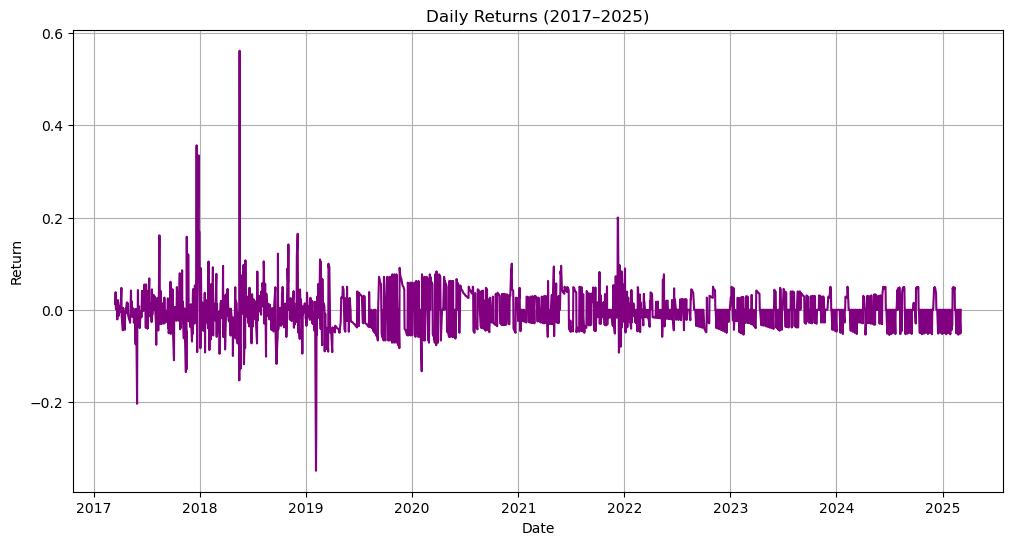

In [20]:
# Line chart (Daily Returns Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'], color='purple')
plt.title("Daily Returns (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid()
plt.show()

In [22]:
# Returns are mostly close to zero, showing no consistent upward or downward movement.
# Frequent small fluctuations indicate regular short-term market activity.
# A few large spikes (both positive and negative) show sudden price changes.
# Higher volatility is visible in the earlier period (around 2017–2019).
# Later years show smaller movements, indicating relatively lower volatility.

### Daily Volatility

In [24]:
daily_vol = data['Daily Return'].std()
print(f"Daily Volatility: {daily_vol*100:.2f}%")

Daily Volatility: 4.34%


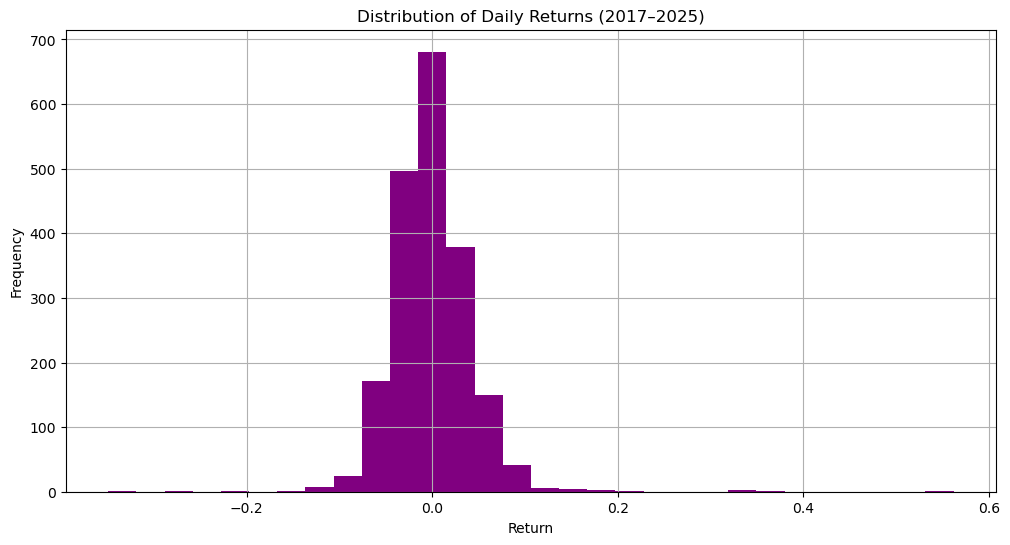

In [26]:
# Histogram (Distribution of Daily Returns)
plt.figure(figsize=(12,6))
plt.hist(data['Daily Return'].dropna(), bins=30, color='purple')
plt.title("Distribution of Daily Returns (2017–2025)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [28]:
# Most returns are concentrated near zero, indicating minimal average change.
# The distribution is roughly balanced, showing similar chances of gains and losses.
# A few extreme values on both sides indicate occasional sharp movements.
# The narrow spread of most data points suggests generally low to moderate volatility.

### Annualized Volatility

In [30]:
annual_vol = daily_vol * np.sqrt(252)
print(f"Annualized Volatility: {annual_vol*100:.2f}%")

Annualized Volatility: 68.92%


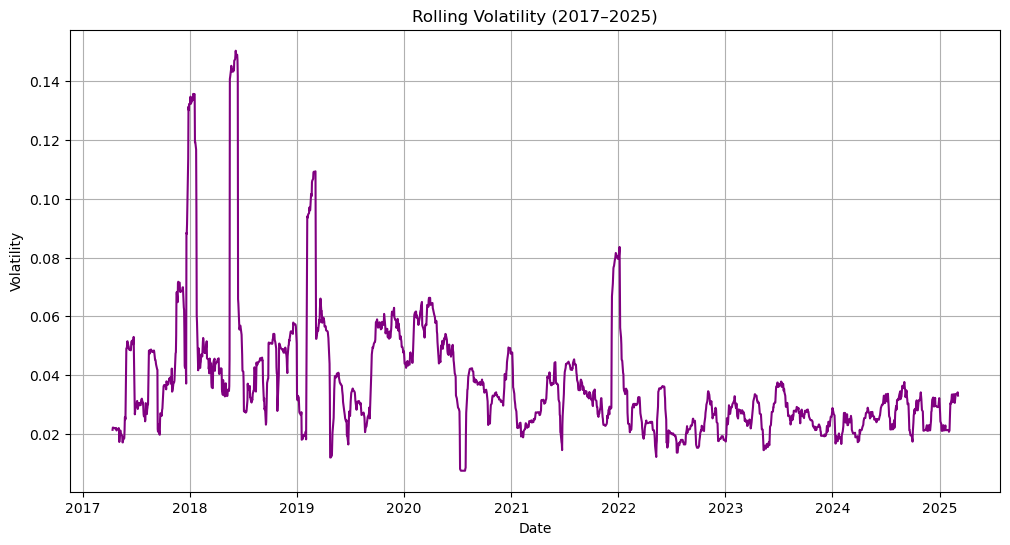

In [32]:
data['Rolling Volatility'] = data['Daily Return'].rolling(20).std()

# Line chart (Rolling Volatility Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Rolling Volatility'], color='purple')
plt.title("Rolling Volatility (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

In [34]:
# Volatility is higher in the earlier years, showing unstable and uncertain price movements.
# Sharp spikes (around 2018–2020) indicate periods of high risk and sudden changes.
# After this period, volatility drops significantly as the stock price falls to low levels.
# In recent years, volatility remains low and stable due to reduced trading activity.
# The overall trend shows decreasing volatility as the company becomes inactive.

### 📊 Conclusion

### Reliance Communications stock shows a strong declining trend.

### - Volatility is high initially, indicating unstable and risky market behavior.

### - Price movements drop sharply and later remain at very low levels with limited activity.

### - Daily returns show mostly small changes with occasional sudden spikes.

### - Overall, the stock moves from high instability to almost no activity, reflecting the behavior of a shutdown company.